 # import python libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import the Dataset

In [2]:
df = pd.read_csv("superstore.csv", encoding="latin1")

# Data exploration

In [3]:
df.shape

(51290, 27)

In [4]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'è®°å½æ°', 'Order.Date', 'Order.ID',
       'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity',
       'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode',
       'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [5]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,è®°å½æ°,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


# check for null values

In [ ]:
df.isnull().sum()

In [6]:
df["è®°å½\x95æ\x95°"]

0        1
1        1
2        1
3        1
4        1
        ..
51285    1
51286    1
51287    1
51288    1
51289    1
Name: è®°å½æ°, Length: 51290, dtype: int64

# Remove uselss column.

In [7]:
df = df.drop("è®°å½\x95æ\x95°", axis=1)

# drop null values

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [8]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

# Summary Statistics for Numerical Variables¶


#  description of the data

In [12]:
df.describe()

,Discount,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [13]:
df["Profit"].sum()

np.float64(1467457.2912800002)

In [14]:
total_profit= df[df["Profit"] > 0]["Profit"].sum()
total_profit

np.float64(2388103.4469999997)

In [15]:
total_loss_abs = df[df["Profit"] < 0]["Profit"].abs().sum()
total_loss_abs 

np.float64(920646.1557200002)

In [16]:
df["Sales"].sum()

np.int64(12642905)

In [ ]:
df["Shipping.Cost"].sum()

In [ ]:
df["Quantity"].sum()

# Exploratory Data Analysis (EDA)

#describe() method returns description of the data in the DataFrame (i.e. count, mean, std, etc)


In [17]:
df.groupby("Product.ID")["Quantity"].sum().sort_values(ascending=False).head()

Product.ID
OFF-AR-10003651    163
OFF-BI-10002799    130
OFF-AR-10003829    117
OFF-BI-10001808    112
OFF-BI-10003708    111
Name: Quantity, dtype: int64

In [18]:
top_5_Category_by_Quantity=df.groupby("Category")["Quantity"].sum().sort_values(ascending=False).head()
top_5_Category_by_Quantity

Category
Office Supplies    108182
Technology          35176
Furniture           34954
Name: Quantity, dtype: int64

In [19]:

top_5_product=df.groupby(["Product.ID","Product.Name"])[["Profit","Sales"]].sum().sort_values(by="Profit", ascending=False).head(5)
#top_5_product.to_csv("top_5_product.csv")
top_5_product

,,Profit,Sales
Product.ID,Product.Name,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,25199.9280,61600
OFF-AP-10004512,"Hoover Stove, Red",10345.5840,21148
TEC-PH-10004823,"Nokia Smart Phone, Full Size",8121.4800,22261
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390,27454
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,6983.8836,18840


In [20]:
top_5_city=df.groupby("City")[["Profit","Sales"]].sum().sort_values(by="Profit", ascending=False).head(10)

#top_5_city.to_csv("top_5_city.csv")
top_5_city

,Profit,Sales
City,,
New York City,62036.98370,256397
Los Angeles,30440.75790,175857
Seattle,29156.09670,119552
Managua,17853.71804,83714
San Francisco,17507.38540,112690
London,17378.71500,86945
Sydney,16002.80700,101952
Vienna,15660.84000,62026
San Salvador,15036.51040,57708


In [21]:
top_5_Country=df.groupby("Country")[["Profit","Sales"]].sum().sort_values(by="Profit", ascending=False).head(5)
#top_5_Country.to_csv("top_5_Country.csv")
top_5_Country



,Profit,Sales
Country,,
United States,286397.0217,2297354
China,150683.0850,700591
India,129071.8350,589664
United Kingdom,111900.1500,528570
France,109029.0030,858930


In [22]:
df.groupby("Category")[["Profit","Sales"]].sum().sort_values(by="Profit", ascending=False).head(10)


,Profit,Sales
Category,,
Technology,663778.73318,4744691
Office Supplies,518473.83430,3787330
Furniture,285204.72380,4110884


In [23]:
top_5_Sup_Category=df.groupby("Sub.Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
top_5_Sup_Category

,Sales,Profit
Sub.Category,,
Phones,1706874,216717.00580
Copiers,1509439,258567.54818
Chairs,1501682,140396.26750
Bookcases,1466559,161924.41950
Storage,1127124,108461.48980
Appliances,1011081,141680.58940
Machines,779071,58867.87300
Tables,757034,-64083.38870
Accessories,749307,129626.30620


In [24]:
df["Order.Date"]=pd.to_datetime(df["Order.Date"])

In [25]:
df["month"]=(df["Order.Date"]).dt.month

In [26]:
df.groupby("month")[["Profit","Sales"]].sum().sort_values(by="Profit", ascending=False).head(12)

,Profit,Sales
month,,
11,175449.48412,1551319
12,170718.12710,1580816
9,170438.18316,1437432
10,157269.35838,1168220
8,151854.10972,1293852
6,147079.41684,1269751
5,104509.78428,904061
3,94087.52096,770519
7,78070.09172,749423


In [27]:
df.groupby("Ship.Mode")[["Profit","Sales"]].sum().sort_values(by="Profit", ascending=False).head(10)

,Profit,Sales
Ship.Mode,,
Standard Class,890596.02120,7578889
Second Class,292583.52708,2565747
First Class,208104.67520,1831067
Same Day,76173.06780,667202


In [28]:
df.groupby("Ship.Mode")["Order.ID"].count().sort_values(ascending=False).head()

Ship.Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: Order.ID, dtype: int64

In [29]:
top_5_Customer=df.groupby("Customer.ID")[["Profit","Sales"]].sum().sort_values(by="Profit", ascending=False).head(10)
#top_5_Customer.to_csv("top_5_Customer.csv")
top_5_Customer



,Profit,Sales
Customer.ID,,
TC-209804,8981.3239,19050
RB-193604,6976.0959,15117
SC-200954,5757.4119,14145
HL-150404,5622.4292,12875
AB-101054,5444.8055,14476
SP-209202,4974.5130,16566
TA-213854,4703.7883,14596
CA-127751,4045.8780,11493
PJ-188352,3986.0040,8509


In [30]:
Sales_by_Segment=df.groupby("Segment")[["Profit","Sales"]].sum().sort_values(by="Sales", ascending=False).head(10)
#Sales_by_Segment.to_csv("Sales_by_Segment.csv")
Sales_by_Segment

,Profit,Sales
Segment,,
Consumer,749239.78206,6508141
Corporate,441208.32866,3824808
Home Office,277009.18056,2309956


In [31]:
loss_10_product=df.groupby(["Product.ID","Product.Name"])["Profit"].sum().sort_values().head(10)

#loss_10_product.to_csv("loss_10_product.csv")
loss_10_product

Product.ID        Product.Name                                            
TEC-MA-10000418   Cubify CubeX 3D Printer Double Head Print                  -8879.9704
OFF-AP-10001623   Hoover Stove, White                                        -4958.1630
TEC-MA-10000822   Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
TEC-PH-10002991   Apple Smart Phone, Full Size                               -4574.6439
TEC-MOT-10003050  Motorola Smart Phone, Cordless                             -3998.6820
TEC-MA-10004125   Cubify CubeX 3D Printer Triple Head Print                  -3839.9904
FUR-CH-10001582   Office Star Executive Leather Armchair, Black              -3066.7830
FUR-TA-10000198   Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
FUR-TA-10002885   Lesro Computer Table, Fully Assembled                      -2798.4880
FUR-TA-10002172   Hon Conference Table, Rectangular                          -2619.3105
Name: Profit, dtype: float64

In [32]:
loss_5_State=df.groupby("State")["Profit"].sum().sort_values().head()
#loss_5_State.to_csv("loss_5_State.csv")
loss_5_State


State
Istanbul   -29033.7000
Lagos      -25922.5110
Texas      -25729.3563
Ohio       -16971.3766
Izmir      -15729.8040
Name: Profit, dtype: float64

In [33]:
loss_5_City=df.groupby("City")["Profit"].sum().sort_values().head()
#loss_5_City.to_csv("loss_5_City.csv")
loss_5_City


City
Lagos          -25922.51100
Istanbul       -19960.90800
Tegucigalpa    -15007.41608
Philadelphia   -13837.76740
Lahore         -13626.37200
Name: Profit, dtype: float64

In [34]:
loss_Customer=df.groupby("Customer.ID")["Profit"].sum().sort_values().head(10)
#loss_Customer.to_csv("loss_Customer.csv")
loss_Customer


Customer.ID
CS-125054   -6626.3895
DM-33452    -5377.6800
GT-146354   -4108.6589
SS-201402   -3957.1380
LF-171854   -3583.9770
SR-204254   -3333.9144
HG-149654   -2797.9635
SN-205601   -2597.1300
MT-80702    -2519.6340
JC-61052    -2470.7340
Name: Profit, dtype: float64

In [35]:
Discount_with_Profit=df.groupby("Discount")[["Profit","Sales"]].sum().sort_values(by="Sales", ascending=False).head(10)


#Discount_with_Profit.to_csv("Discount_with_Profit.csv")
Discount_with_Profit

,Profit,Sales
Discount,,
0.000,1.770695e+06,6992734
0.100,2.590642e+05,1579618
0.200,1.177159e+05,1203855
0.400,-1.437485e+05,559557
0.500,-1.586299e+05,324145
0.150,2.737590e+04,306037
0.002,5.797658e+04,261395
0.170,2.816307e+04,247404
0.300,-1.968585e+04,188913


In [36]:
df["Ship.Date"] = pd.to_datetime(df["Ship.Date"])
df["Order.Date"] = pd.to_datetime(df["Order.Date"])

df["Ship_Days"] = (df["Ship.Date"] - df["Order.Date"]).dt.days

ship_mod_with_profit=df.groupby("Ship.Mode")[["Ship_Days", "Profit"]].mean()
#ship_mod_with_profit.to_csv("ship mod with Profit.csv")
ship_mod_with_profit


,Ship_Days,Profit
Ship.Mode,,
First Class,2.181746,27.728804
Same Day,0.037394,28.201802
Second Class,3.230187,28.381368
Standard Class,4.998018,28.938945


In [37]:
df["Ship.Duration"] = df["Ship.Date"] - df["Order.Date"]
df["Ship.Duration"].mean()

Timedelta('3 days 23:15:53.589393644')

In [38]:
df.groupby("Ship.Date")[["Sales","Shipping.Cost"]].sum()

,Sales,Shipping.Cost
Ship.Date,,
2011-01-03,312,132.780
2011-01-05,111,12.990
2011-01-06,722,59.560
2011-01-07,2879,219.342
2011-01-08,1793,113.574
...,...,...
2015-01-03,10276,1164.588
2015-01-04,9348,569.186
2015-01-05,4030,326.701


In [39]:
(df["Shipping.Cost"] > df["Profit"]).sum()   # طلبات خاسرة بسبب الشحن


np.int64(21150)

In [40]:
loss = df[df["Profit"] < 0]

loss_reason = loss.groupby(["Category", "Sub.Category"])["Profit"].sum().sort_values()

#loss_reason.to_csv("loss_reason.csv")
loss_reason

Category         Sub.Category
Furniture        Tables         -144123.14860
                 Bookcases      -101446.29730
Technology       Phones          -96417.66010
Furniture        Chairs          -96084.89690
Technology       Machines        -78672.74030
Office Supplies  Storage         -76063.97800
Technology       Copiers         -71547.49982
Office Supplies  Appliances      -63991.69040
                 Binders         -52884.06130
Technology       Accessories     -39857.49820
Furniture        Furnishings     -28514.49690
Office Supplies  Art             -21660.62770
                 Supplies        -18184.43100
                 Envelopes       -10863.56550
                 Paper           -10299.49370
                 Fasteners        -6273.29990
                 Labels           -3760.77010
Name: Profit, dtype: float64

# Visualizations

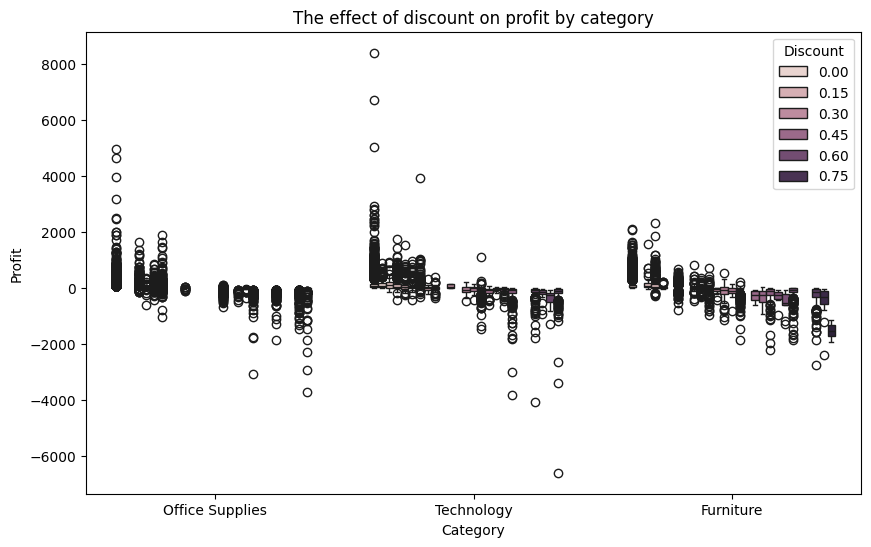

In [41]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Category', y='Profit', hue='Discount')
plt.title("The effect of discount on profit by category")
plt.show()

<Axes: xlabel='Order.Date'>

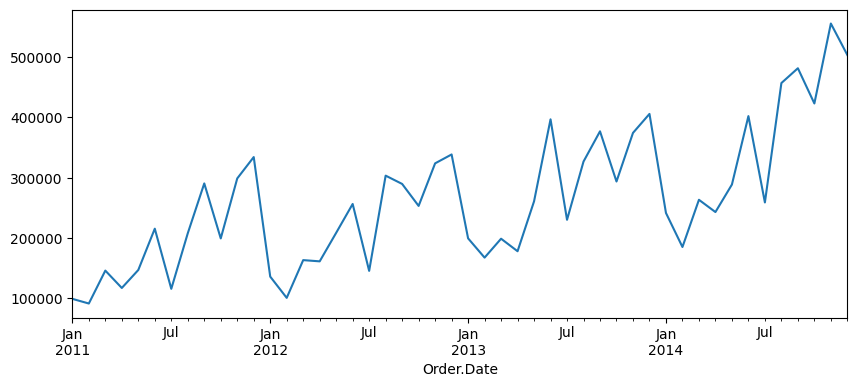

In [42]:
monthly_sales = df.groupby(df["Order.Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.plot(figsize=(10,4))

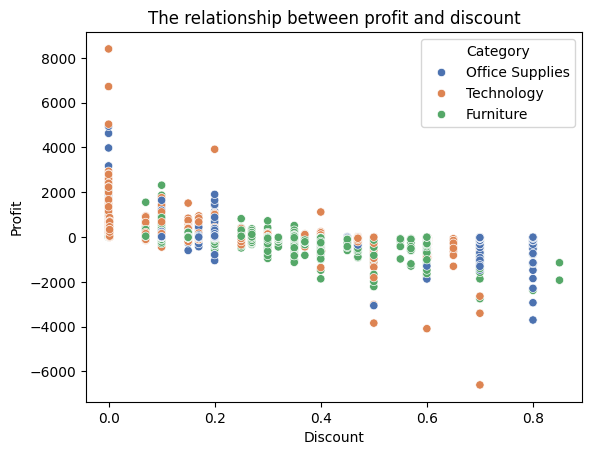

In [43]:
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category", palette="deep")
plt.title("The relationship between profit and discount")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

C:\Users\medos\AppData\Local\Temp\ipykernel_15020\2952370301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette="viridis")


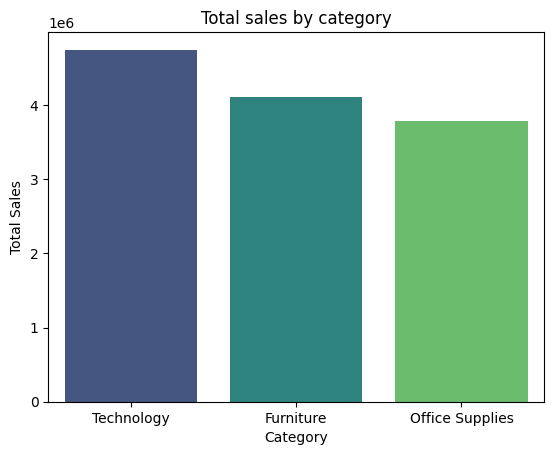

In [44]:
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette="viridis")
plt.title("Total sales by category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

C:\Users\medos\AppData\Local\Temp\ipykernel_15020\1458647729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_region.index, y=profit_by_region.values, palette="magma")


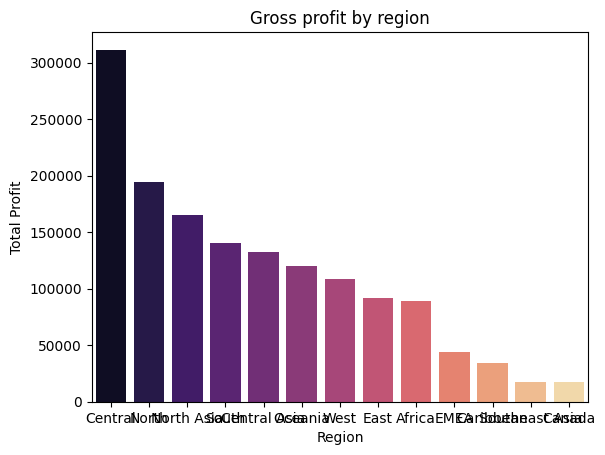

In [45]:
profit_by_region = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
sns.barplot(x=profit_by_region.index, y=profit_by_region.values, palette="magma")
plt.title("Gross profit by region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

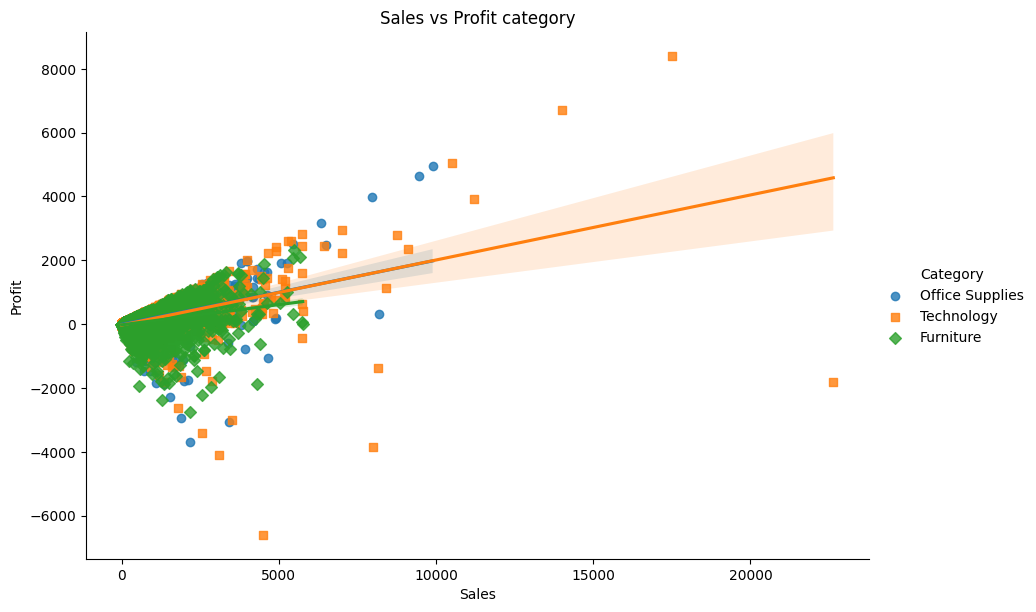

In [46]:
sns.lmplot(data=df, x="Sales", y="Profit", hue="Category", height=6, aspect=1.5, markers=["o","s","D"])
plt.title("Sales vs Profit category")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

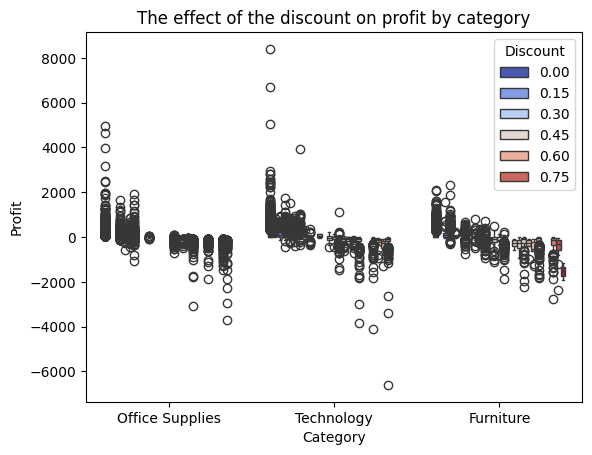

In [47]:
sns.boxplot(data=df, x="Category", y="Profit", hue="Discount", palette="coolwarm")
plt.title("The effect of the discount on profit by category")
plt.show()

# Export Results

In [48]:
loss_reason.to_csv("output Data Files/loss_reason.csv")
ship_mod_with_profit.to_csv("output Data Files/ship mod with Profit.csv")
Discount_with_Profit.to_csv("output Data Files/Discount_with_Profit.csv")
loss_Customer.to_csv("output Data Files/loss_Customer.csv")
loss_5_City.to_csv("output Data Files/loss_5_City.csv")
loss_5_State.to_csv("output Data Files/loss_5_State.csv")
loss_10_product.to_csv("output Data Files/loss_10_product.csv")
Sales_by_Segment.to_csv("output Data Files/Sales_by_Segment.csv")
top_5_Country.to_csv("output Data Files/top_5_Country.csv")
top_5_city.to_csv("output Data Files/top_5_city.csv")
top_5_product.to_csv("output Data Files/top_5_product.csv")


# Export Final Clean Dataset

In [49]:
df.to_csv("output Data Files/Clean_superstore.csv")

# Summary — Final Conclusions

### Key Findings:
- Most Profitable Category: Furniture / Office Supplies
- Top Selling Cities: Based on analysis, but often New York and Los Angeles
- Top Losing Products: Include heavy and high-cost items
- High Discounts Cause a Significant Decrease in Profitability
- Shipping Time (Ship_Days) Has a Minor Relationship to Profitability
- Monthly Sales Often Increase at Year-End

### Recommendations:
- Reduce High Discounts
- Focus on High-Demand Cities
- Improve Profit Margins for Losing Products
- Improve Shipping Times in Areas with Delays